<a href="https://colab.research.google.com/github/mkhairel/Predicting-Residential-Property-Prices-in-Malaysia/blob/main/Predicting-Residential-Property-Prices-in-Malaysia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Data Preparation & Data Cleaning

import pandas as pd

#Loading Data Method 1: MyDrive Upload

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Colab Data/Malaysia_property_data.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import io
df = pd.read_csv('/content/drive/MyDrive/Colab Data/Malaysia_property_data.csv')

In [ ]:
#Data Inspection

import pandas as pd
import io

# The 'df' DataFrame is already loaded from previous cells.
# This section was for interactive file upload, which is not being used here.
# file_name = list(uploaded.keys())[0]
# df = pd.read_csv(io.BytesIO(uploaded[file_name]))

df.head()  # First 5 rows

df.tail(3)  # Last 3 rows

df.info()  # Quick info

df.describe()  # Data Types


# Column names
print("Columns:", list(df.columns))

# Colum
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7353 entries, 0 to 7352
Data columns (total 48 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   original_link                   3935 non-null   object 
 1   price                           7353 non-null   int64  
 2   description                     7353 non-null   object 
 3   images                          3935 non-null   object 
 4   property_type                   7353 non-null   object 
 5   car_parks                       3680 non-null   float64
 6   built_up_area                   6334 non-null   float64
 7   lot_type                        4772 non-null   object 
 8   furnishing                      7353 non-null   object 
 9   tenure                          6505 non-null   object 
 10  land_area                       4869 non-null   float64
 11  land_title                      2641 non-null   object 
 12  title_type                      25

In [ ]:
# remove missing values
df_clean = df.dropna()
print(f"Original: {df.shape}, Cleaned: {df_clean.shape}")

# Fill numeric columns with mean
numeric_cols = df.select_dtypes(include=['number']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# Fill text columns with mode
text_cols = df.select_dtypes(include=['object']).columns
for col in text_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Count duplicates
print(f"Total duplicates: {df.duplicated().sum()}")

# See duplicate rows
duplicates = df[df.duplicated(keep=False)]  # keep=False shows all dupes
duplicates.head()

# Remove (keeping first)
df = df.drop_duplicates()
print(f"After cleaning: {df.shape}")

Original: (7353, 48), Cleaned: (38, 48)
Total duplicates: 2
After cleaning: (7351, 48)


In [ ]:
import pandas as pd

# Columns to analyze from the remaining DataFrame
columns_to_analyze = ['district', 'state']

print("--- Unique Values and Top 20 Common Values ---")
for col in columns_to_analyze:
    print(f"\nColumn: '{col}'")
    print(f"Number of unique values: {df[col].nunique()}")
    print(f"Top 20 most common values:\n{df[col].value_counts().head(20)}")


# --- Standardization Function ---
def standardize_text(text):
    if pd.isna(text):
        return text
    if isinstance(text, str):
        text = text.lower()  # Convert to lowercase
        text = text.strip()  # Remove leading/trailing whitespace
        return text
    return text # Return non-string, non-NaN values as is

print("\n--- Detecting Inconsistent Values and Standardization ---")
# Apply standardization and observe changes in unique counts
for col in columns_to_analyze:
    original_nunique = df[col].nunique()
    # Create a temporary standardized column for comparison
    df[f'{col}_standardized'] = df[col].apply(standardize_text)
    standardized_nunique = df[f'{col}_standardized'].nunique()
    print(f"\nColumn '{col}':")
    print(f"  Original unique count: {original_nunique}")
    print(f"  Standardized unique count: {standardized_nunique}")
    if original_nunique != standardized_nunique:
        print("  Inconsistencies (case sensitivity, spacing) detected and partially handled.")
        print(f"  Top 10 values after standardization for '{col}':\n{df[f'{col}_standardized'].value_counts().head(10)}")
    else:
        print("  No significant inconsistencies (case sensitivity, spacing) detected after basic standardization.")

# --- Manual Mapping for State Column Inconsistencies ---
# Based on inspection, we need to unify certain state names, including newly identified ones
state_mapping = {
    'johor darul ta\'zim': 'johor',
    'kedah darul aman': 'kedah',
    'kelantan darul naim': 'kelantan',
    'melaka': 'melaka',
    'negeri sembilan': 'negeri sembilan',
    'pahang': 'pahang',
    'perak darul ridzuan': 'perak',
    'perlis': 'perlis',
    'pulau pinang': 'pulau pinang',
    'sabah': 'sabah',
    'sarawak': 'sarawak',
    'selangor': 'selangor',
    'terengganu darul iman': 'terengganu',
    'wilayah persekutuan kuala lumpur': 'kuala lumpur',
    'wp kuala lumpur': 'kuala lumpur',
    'kuala lumpur': 'kuala lumpur',
    'wilayah persekutuan putrajaya': 'putrajaya',
    'wp putrajaya': 'putrajaya',
    'putrajaya': 'putrajaya',
    'wilayah persekutuan labuan': 'labuan',
    'wp labuan': 'labuan',
    'labuan': 'labuan',
    'paka': 'terengganu', # Paka is a district in Terengganu, likely a misclassification
    'federal territory of kuala lumpur': 'kuala lumpur', # New addition
    'malacca': 'melaka', # New addition
    'penang': 'pulau pinang', # New addition
    'jb': 'johor', # New addition, assuming 'jb' in state column refers to Johor
    'wilayah persekutuan': 'kuala lumpur' # New addition, mapping general federal territory to KL for now
}

df['state_standardized'] = df['state_standardized'].replace(state_mapping)
print("\nState column after manual mapping and standardization:")
print(df['state_standardized'].value_counts())

# --- Remove truly foreign data ---
malaysian_states_for_filter = [
    'johor', 'kedah', 'kelantan', 'melaka', 'negeri sembilan', 'pahang',
    'perak', 'perlis', 'pulau pinang', 'sabah', 'sarawak', 'selangor',
    'terengganu', 'kuala lumpur', 'putrajaya', 'labuan'
]

initial_rows_count = df.shape[0]
# Explicitly use .copy() to prevent SettingWithCopyWarning
df = df[df['state_standardized'].isin(malaysian_states_for_filter)].copy()
print(f"Removed {initial_rows_count - df.shape[0]} rows containing non-Malaysian states after re-mapping.")

# --- Replace original columns with standardized versions and drop temporary columns ---
df['district'] = df['district_standardized']
df['state'] = df['state_standardized']
df = df.drop(columns=[col + '_standardized' for col in columns_to_analyze])

print("\nDataFrame head after full standardization and column replacement:")
print(df[['district', 'state']].head())
print(f"\nDataFrame info after full standardization: {df.shape}")
df.info()

--- Unique Values and Top 20 Common Values ---

Column: 'district'
Number of unique values: 77
Top 20 most common values:
district
petaling                  1157
johor bahru                922
kuala lumpur               609
melaka tengah              532
putrajaya                  446
seremban                   429
hulu langat                344
timur laut                 336
kuching                    278
kuantan                    266
klang                      225
seberang perai tengah      169
sepang                     167
kota kinabalu              149
kota setar                 121
barat daya                  98
seberang perai selatan      93
gombak                      82
jasin                       80
penampang                   71
Name: count, dtype: int64

Column: 'state'
Number of unique values: 26
Top 20 most common values:
state
Selangor                             2011
Johor Darul Ta'zim                    750
Pulau Pinang                          636
Wilayah Persekutuan

In [ ]:
columns_to_check = ['district', 'state']

print("--- Current Unique Values and Top 20 Common Values ---")
for col in columns_to_check:
    print(f"\nColumn: '{col}'")
    print(f"Number of unique values: {df[col].nunique()}")
    print(f"Top 20 most common values:\n{df[col].value_counts().head(20)}")

print("\n--- Checking for Inconsistent Values, Typos, and Format Differences ---")
print("For `district` and `state` columns, basic standardization (lowercase, strip whitespace) and manual mapping for `state` have been applied in previous steps. This addresses most case sensitivity, spacing, and common abbreviation inconsistencies.")
print("\nReviewing `value_counts()` from above will help identify any remaining semantic inconsistencies or typos not covered by the initial standardization or manual mapping.")

# --- Checking for Foreign Data in 'state' ---
print("\n--- Checking for Foreign Data (States) ---")
malaysian_states = [
    'johor', 'kedah', 'kelantan', 'melaka', 'negeri sembilan', 'pahang',
    'perak', 'perlis', 'pulau pinang', 'sabah', 'sarawak', 'selangor',
    'terengganu', 'kuala lumpur', 'putrajaya', 'labuan'
]

# Filter for states that are not in our known list of Malaysian states
foreign_states = df[~df['state'].isin(malaysian_states)]['state'].unique()
if len(foreign_states) > 0:
    print(f"Potential foreign or unlisted states found: {foreign_states}")
else:
    print("All 'state' values appear to be valid Malaysian states after cleaning.")


--- Current Unique Values and Top 20 Common Values ---

Column: 'district'
Number of unique values: 77
Top 20 most common values:
district
petaling                  1156
johor bahru                922
kuala lumpur               609
melaka tengah              532
putrajaya                  446
seremban                   429
hulu langat                343
timur laut                 336
kuching                    276
kuantan                    265
klang                      225
seberang perai tengah      169
sepang                     167
kota kinabalu              149
kota setar                 121
barat daya                  98
seberang perai selatan      93
gombak                      82
jasin                       80
penampang                   71
Name: count, dtype: int64

Column: 'state'
Number of unique values: 15
Top 20 most common values:
state
selangor           2011
johor              1019
pulau pinang        752
melaka              662
kuala lumpur        644
negeri sembilan  

In [ ]:
print("\nFINAL SHAPE:", df.shape)

# Using 'columns_to_check' which was defined earlier in the notebook
for col in columns_to_check:
    print(f"\n{col.upper()} VALUE COUNTS:")
    print(df[col].value_counts().head(10))


FINAL SHAPE: (7346, 48)

DISTRICT VALUE COUNTS:
district
petaling         1156
johor bahru       922
kuala lumpur      609
melaka tengah     532
putrajaya         446
seremban          429
hulu langat       343
timur laut        336
kuching           276
kuantan           265
Name: count, dtype: int64

STATE VALUE COUNTS:
state
selangor           2011
johor              1019
pulau pinang        752
melaka              662
kuala lumpur        644
negeri sembilan     455
putrajaya           448
pahang              374
sarawak             323
sabah               233
Name: count, dtype: int64


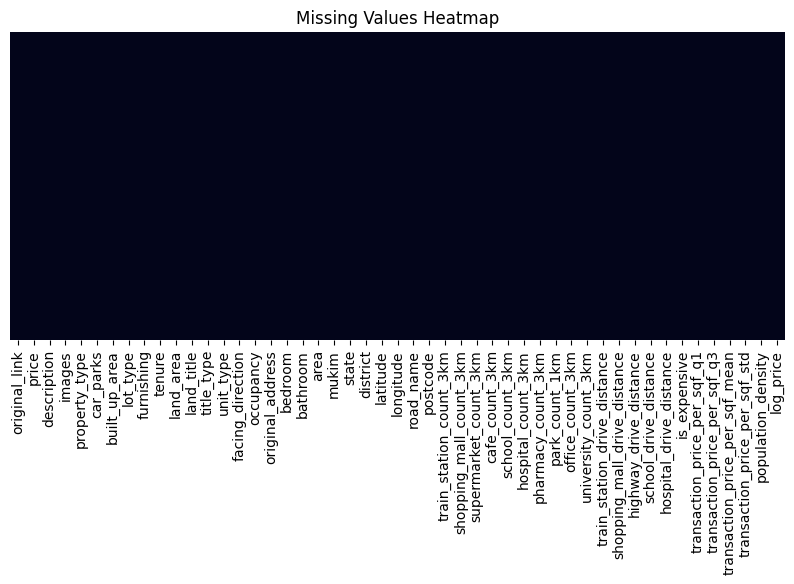

In [ ]:
# Visualize (Colab shows plot inline)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title("Missing Values Heatmap")
plt.show()

In [ ]:
# Save as CSV
df.to_csv('cleaned_data.csv', index=False)

# Download to computer
from google.colab import files
files.download('cleaned_data.csv')

# Save to Drive
df.to_csv('/content/drive/MyDrive/Colab Data/cleaned_data.csv', index=False)
print("Saved to Google Drive!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved to Google Drive!


In [ ]:
#Analysis & Visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Iterate through the files uploaded by the user
for fn in uploaded.keys():
  # Check if the uploaded file is the expected 'malaysian_online_shopping_2025.csv'
  if fn == 'cleaned_data.csv':
    # Confirm the successful upload of the correct file
    print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
    # Read the CSV file into a pandas DataFrame using io.BytesIO to handle the uploaded file content
    df = pd.read_csv(io.BytesIO(uploaded[fn]))
    # Confirm that the dataset has been loaded successfully
    print("Dataset 'cleaned_data.csv' loaded successfully.")
    # Display the first few rows of the DataFrame to verify data loading
    print(df.head())
  else:
    # Inform the user if an incorrect file was uploaded and prompt for the correct one
    print(f"Skipping uploaded file: {fn}. Please upload 'malaysian_online_shopping_2025.csv'.")

User uploaded file "cleaned_data.csv" with length 32008121 bytes
Dataset 'cleaned_data.csv' loaded successfully.
                                       original_link    price  \
0  https://www.edgeprop.my/listing/sale/3577744/j...  1000000   
1  https://www.edgeprop.my/listing/sale/3577718/j...   920000   
2  https://www.edgeprop.my/listing/sale/3577802/j...   980000   
3  https://www.edgeprop.my/listing/sale/3415255/j...   590000   
4  https://www.edgeprop.my/listing/sale/3414746/j...   328000   

                                         description  \
0  TAMAN SUTERA (PERLING), JB (JALAN SUTERA UNGU)...   
1  TAMAN SUTERA (PERLING), JB (JALAN SUTERA UNGU)...   
2  TAMAN SUTERA (PERLING), JB (JALAN SUTERA UNGU)...   
3  Brand New Double Storey @ Eco Tropics Morrison...   
4   Rare unit! Double storey low cost house for s...   

                                              images   property_type  \
0  https://d5dkjitd3iude.cloudfront.net/eyJidWNrZ...   Terrace House   
1  https://d5dk

In [ ]:
# Descriptive statistics for numerical columns
print("--- Descriptive Statistics for Numerical Columns ---")
print(df.describe())
print("\nExplanation: This table provides a statistical summary for all numerical columns. It includes count (number of non-null values), mean (average), std (standard deviation), min (minimum value), 25% (first quartile), 50% (median), 75% (third quartile), and max (maximum value). This helps understand the distribution, central tendency, and spread of numerical data.\n")

# Value counts for categorical columns
categorical_cols = ['state', 'area', 'property_type']

print("--- Value Counts for Categorical Columns ---")
for col in categorical_cols:
    print(f"\nColumn: '{col}'")
    print(df[col].value_counts())
print("\nExplanation: For each specified categorical column, 'value_counts()' shows the unique categories and the number of times each category appears in the dataset. This helps identify the most frequent categories and the distribution across different groups.\n")

# Describe the target variable (price)
print("--- Description of the Target Variable: 'price' ---")
price_stats = df['price'].describe()
print(price_stats)

# Extract and explain specific statistics for 'price'
price_min = price_stats['min']
price_max = price_stats['max']
price_mean = price_stats['mean']
price_median = price_stats['50%']

print(f"\nSpecific Statistics for 'price':")
print(f"  - Minimum Price: RM {price_min:,.2f}")
print(f"  - Maximum Price: RM {price_max:,.2f}")
print(f"  - Mean Price: RM {price_mean:,.2f}")
print(f"  - Median Price (50th percentile): RM {price_median:,.2f}")

print("\nExplanation: The 'price' column is your target variable. This summary tells us:")
print("  - **Count**: Total number of property prices recorded.")
print("  - **Mean**: The average property price.")
print("  - **Std**: The standard deviation, which measures the dispersion or spread of prices around the mean.")
print("  - **Min**: The lowest property price.")
print("  - **25% (Q1)**: The price below which 25% of the properties fall.")
print("  - **50% (Median)**: The middle property price when all prices are sorted. It's often a better measure of central tendency than the mean for skewed data.")
print("  - **75% (Q3)**: The price below which 75% of the properties fall.")
print("  - **Max**: The highest property price.")
print("This gives a clear picture of the typical price range and variability of properties in the dataset.")

print("\n--- Price Distribution Skewness Interpretation ---")
if price_mean > price_median:
    print(f"The mean price (RM {price_mean:,.2f}) is greater than the median price (RM {price_median:,.2f}).")
    print("This suggests that the distribution of property prices is likely **right-skewed (positively skewed)**.")
    print("A right-skewed distribution indicates that there are a higher number of properties at lower price points, with a 'long tail' extending towards higher-priced properties.")
    print("This is common in real estate markets, where a few very expensive properties can pull the average (mean) upwards, while the majority of properties are more affordably priced, closer to the median.")
elif price_mean < price_median:
    print(f"The mean price (RM {price_mean:,.2f}) is less than the median price (RM {price_median:,.2f}).")
    print("This suggests that the distribution of property prices is likely **left-skewed (negatively skewed)**.")
    print("A left-skewed distribution would indicate more properties at higher price points and a tail towards lower prices.")
else:
    print(f"The mean price (RM {price_mean:,.2f}) is approximately equal to the median price (RM {price_median:,.2f}).")
    print("This suggests that the distribution of property prices is relatively **symmetrical (close to normal)**.")


--- Descriptive Statistics for Numerical Columns ---
              price    car_parks  built_up_area      land_area      bedroom  \
count  7.346000e+03  7346.000000    7346.000000    7346.000000  7346.000000   
mean   1.056392e+06     2.133814    2342.444164    3368.072704     4.059738   
std    1.132941e+06     0.919604    7086.656943    5449.129377     1.346772   
min    2.000000e+05     1.000000       1.000000       1.000000    -1.000000   
25%    4.680000e+05     2.000000    1237.000000    1650.000000     3.000000   
50%    6.800000e+05     2.000000    2070.000000    3368.406394     4.000000   
75%    1.200000e+06     2.000000    2640.000000    3368.406394     5.000000   
max    1.190000e+07    20.000000  541000.000000  167996.000000    18.000000   

          bathroom     latitude    longitude      postcode  \
count  7346.000000  7346.000000  7346.000000   7346.000000   
mean      3.238999     3.197898   102.767445  53543.567070   
std       1.466218     1.317107     3.129672  246


--- Exploratory Data Visualizations for Malaysian Property Prices ---



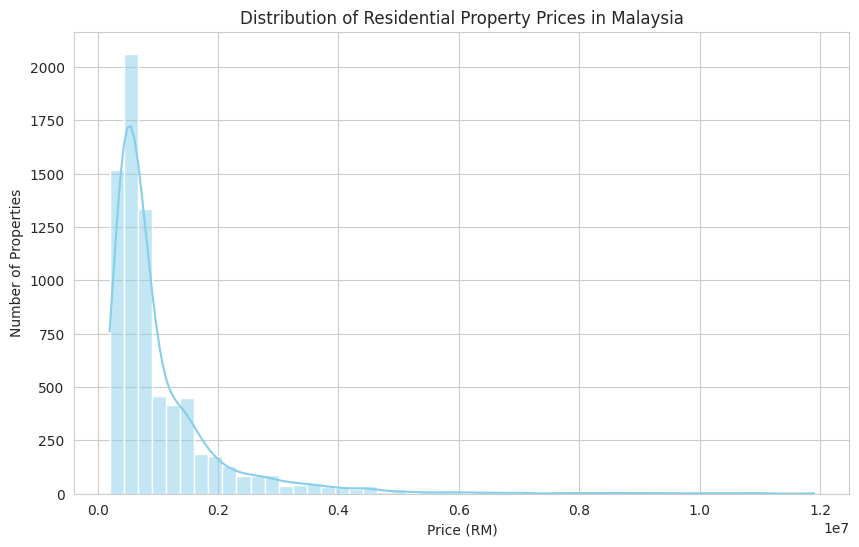

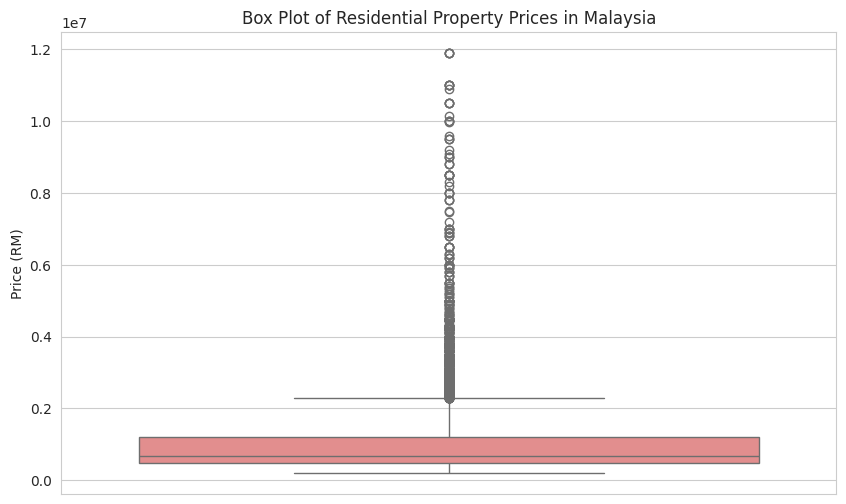

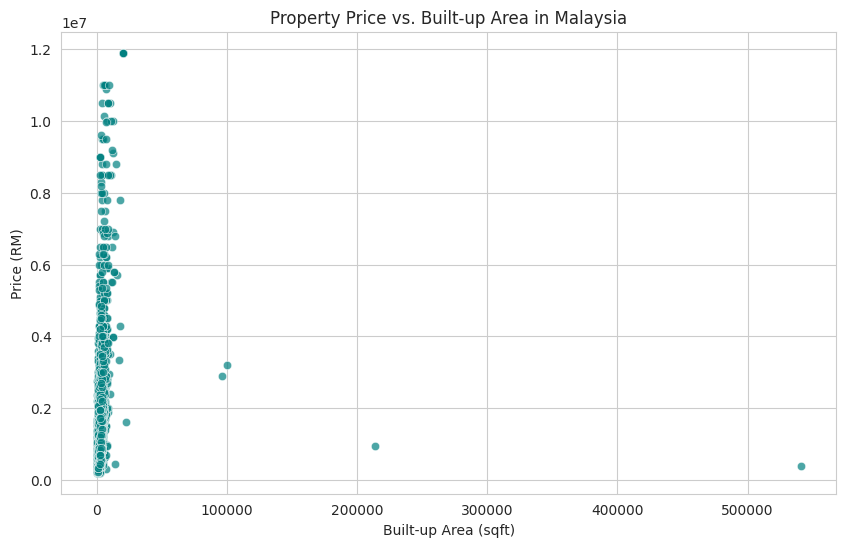

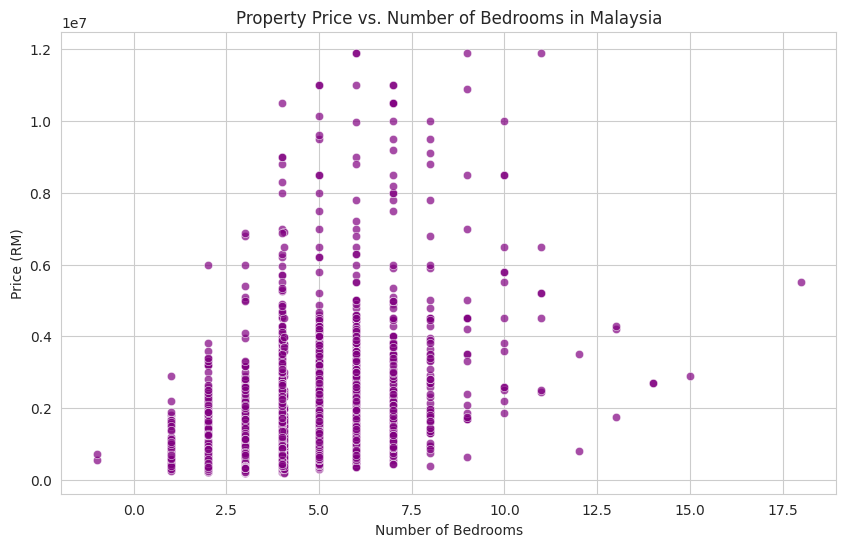

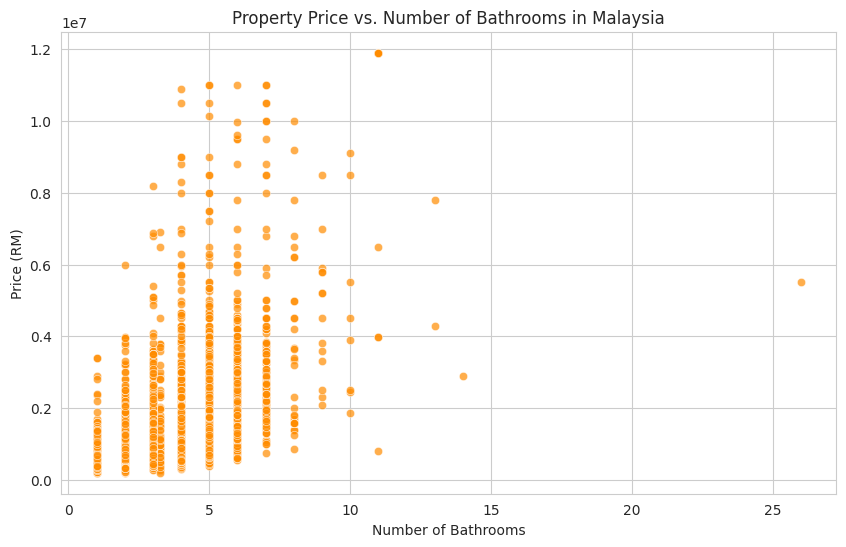

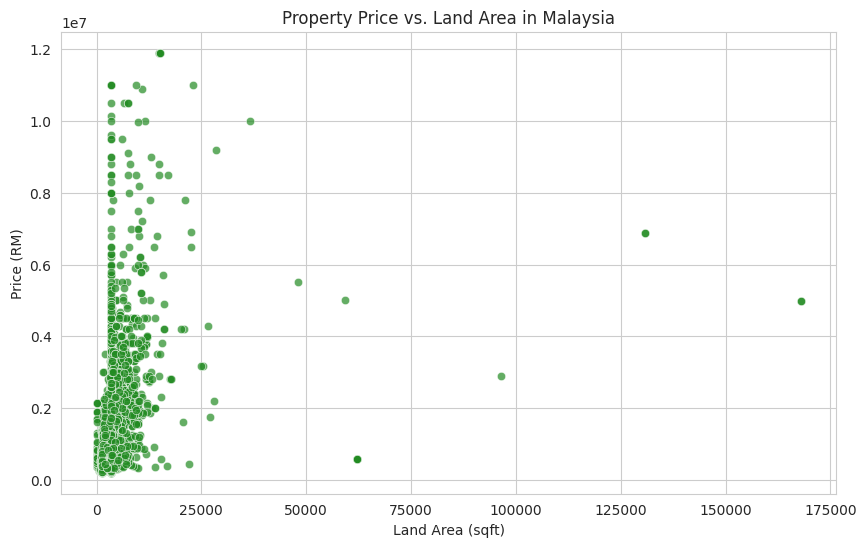

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean and readable style for the plots
sns.set_style("whitegrid")

print("\n--- Exploratory Data Visualizations for Malaysian Property Prices ---\n")

# 1. Histogram for the target variable (price)
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of Residential Property Prices in Malaysia')
plt.xlabel('Price (RM)')
plt.ylabel('Number of Properties')
plt.grid(True)
plt.show()
# Explanation:
# This histogram shows the overall distribution of property prices. A right-skewed distribution (more properties at lower prices with a tail towards higher prices) is common in real estate, indicating that a few very expensive properties can pull the average price up, while most properties are in a more affordable range.

# 2. Box Plot for price to detect outliers
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['price'], color='lightcoral')
plt.title('Box Plot of Residential Property Prices in Malaysia')
plt.ylabel('Price (RM)')
plt.show()
# Explanation:
# The box plot visualizes the median (middle line), interquartile range (IQR, the box), and potential outliers (points beyond the whiskers). Outliers typically represent unusually high or low-priced properties. For Malaysian property, these might be luxury homes or distressed sales. Given the capping applied earlier, we expect fewer extreme outliers.

# 3. Scatter Plot: Price vs. Built-up Area
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['built_up_area'], y=df['price'], alpha=0.7, color='teal')
plt.title('Property Price vs. Built-up Area in Malaysia')
plt.xlabel('Built-up Area (sqft)')
plt.ylabel('Price (RM)')
plt.grid(True)
plt.show()
# Explanation:
# This scatter plot helps visualize the relationship between property size (built-up area) and its price. We generally expect a positive correlation, meaning larger properties tend to be more expensive. Deviations from this trend could indicate premium locations, unique property types, or distressed sales.

# 4. Scatter Plot: Price vs. Number of Bedrooms
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['bedroom'], y=df['price'], alpha=0.7, color='purple')
plt.title('Property Price vs. Number of Bedrooms in Malaysia')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Price (RM)')
plt.grid(True)
plt.show()
# Explanation:
# This plot shows how the number of bedrooms relates to property price. More bedrooms often correlate with higher prices, especially for family homes. However, properties with very few bedrooms might be apartments in prime locations, which could still command high prices, while very many bedrooms could indicate multi-unit properties or larger bungalows.

# 5. Scatter Plot: Price vs. Number of Bathrooms
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['bathroom'], y=df['price'], alpha=0.7, color='darkorange')
plt.title('Property Price vs. Number of Bathrooms in Malaysia')
plt.xlabel('Number of Bathrooms')
plt.ylabel('Price (RM)')
plt.grid(True)
plt.show()
# Explanation:
# Similar to bedrooms, a higher number of bathrooms is generally associated with larger and more luxurious properties, hence potentially higher prices. This plot helps confirm this expected positive relationship within the Malaysian property market.

# 6. Scatter Plot: Price vs. Land Area (if available and relevant)
# Checking if 'land_area' is a suitable numerical feature. If it was largely imputed or not meaningful for all property types, this might be less insightful.
if 'land_area' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=df['land_area'], y=df['price'], alpha=0.7, color='forestgreen')
    plt.title('Property Price vs. Land Area in Malaysia')
    plt.xlabel('Land Area (sqft)')
    plt.ylabel('Price (RM)')
    plt.grid(True)
    plt.show()
    # Explanation:
    # For landed properties, land area is a crucial price determinant. Larger land parcels often lead to higher property values. This plot helps understand this relationship, especially for bungalows and terrace houses in Malaysia.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

print("\n--- Correlation Analysis and Visualization ---\n")

# Define the columns for correlation analysis.
# These include the target variable 'price' and other key numerical features identified in EDA.
correlation_cols = ['price', 'built_up_area', 'bedroom', 'bathroom', 'land_area',
                    'train_station_count_3km', 'shopping_mall_count_3km', 'school_count_3km',
                    'hospital_count_3km', 'population_density']

# Calculate the correlation matrix for the selected columns
correlation_matrix = df[correlation_cols].corr()

print("Correlation Matrix:")
print(correlation_matrix.round(2))

# Explanation of the Correlation Heatmap:
print("\nExplanation of the Correlation Heatmap:")
print("  - This visually represents the Pearson correlation coefficients between different numerical variables.")
print("  - The values range from -1 to 1:")
print("    - A value close to 1 (warm colors like red) indicates a strong positive correlation (as one variable increases, the other tends to increase).")
print("    - A value close to -1 (cool colors like blue) indicates a strong negative correlation (as one variable increases, the other tends to decrease).")
print("    - A value close to 0 (lighter colors) indicates a weak or no linear correlation.")
print("  - **Key Insights for Malaysian Property Prices:**")
print("    - **'price' vs. 'built_up_area', 'bedroom', 'bathroom', 'land_area'**: Expect positive correlations. Larger properties, more rooms/bathrooms, and bigger land areas generally lead to higher prices.")
print("    - **'price' vs. Proximity Features (e.g., shopping_mall_count_3km, school_count_3km)**: Higher counts of amenities nearby often correlate positively with property prices, indicating desirable locations. However, the `_drive_distance` metrics would show negative correlation with price (shorter distance, higher price).")
print("    - **'population_density'**: This could have a positive or negative correlation depending on whether high density is associated with premium urban locations or overcrowded, less desirable areas. Further investigation might be needed.")
print("  - High correlation between independent variables (multicollinearity) should be noted, as it can affect certain regression models. For instance, 'bedroom' and 'bathroom' are often highly correlated with 'built_up_area'.")


--- Correlation Analysis and Visualization ---

Correlation Matrix:
                         price  built_up_area  bedroom  bathroom  land_area  \
price                     1.00           0.13     0.48      0.59       0.25   
built_up_area             0.13           1.00     0.12      0.14       0.07   
bedroom                   0.48           0.12     1.00      0.80       0.14   
bathroom                  0.59           0.14     0.80      1.00       0.14   
land_area                 0.25           0.07     0.14      0.14       1.00   
train_station_count_3km   0.32          -0.01    -0.10     -0.02       0.01   
shopping_mall_count_3km   0.34          -0.01    -0.12     -0.03       0.04   
school_count_3km          0.30          -0.02    -0.11     -0.05      -0.00   
hospital_count_3km        0.27          -0.01    -0.10     -0.03       0.02   
population_density        0.38          -0.01    -0.03      0.05       0.01   

                         train_station_count_3km  shopping_ma


--- Correlation Heatmap: Amenity Count Features ---



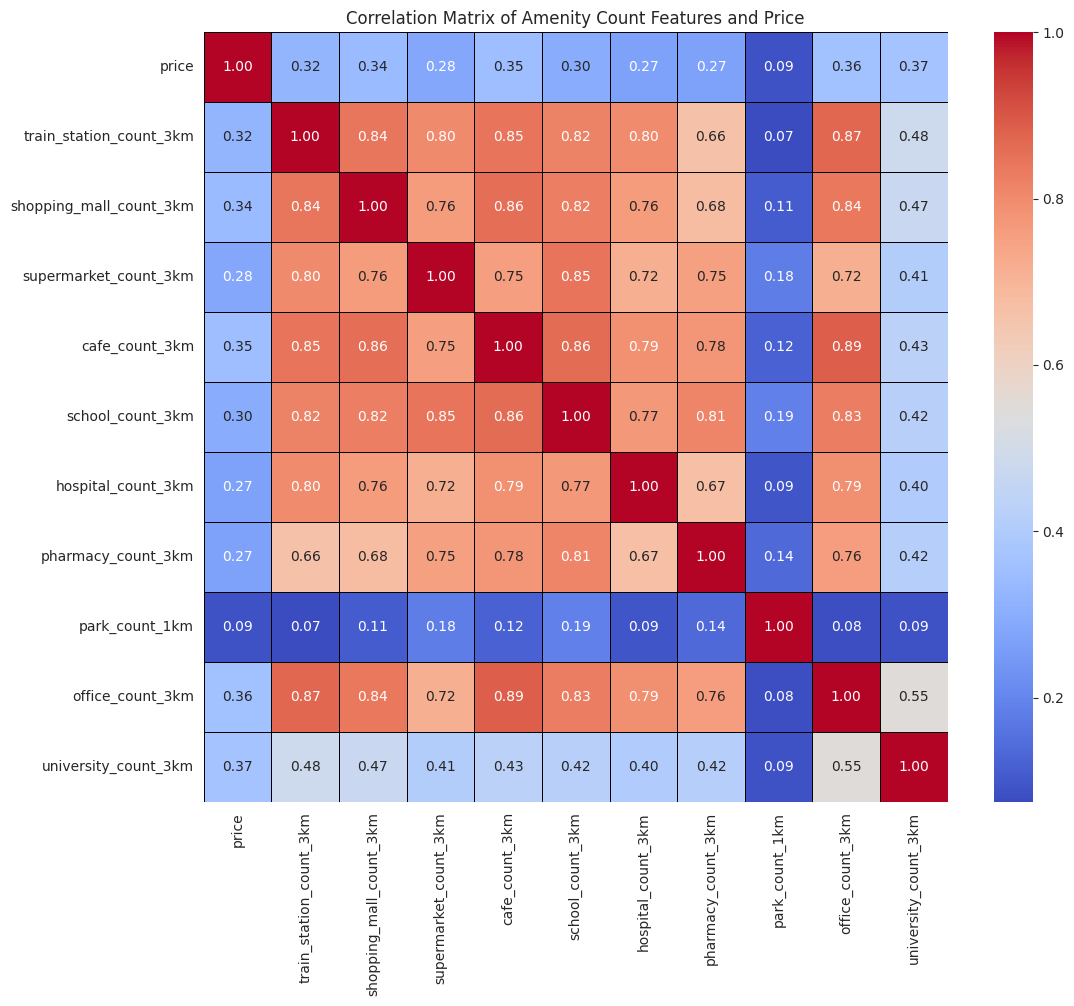

Explanation of Amenity Count Correlation Heatmap:
  - This heatmap illustrates the correlation between property prices and the number of various amenities within a certain radius (e.g., 3km).
  - A positive correlation with 'price' is expected for most amenity counts, as more facilities typically indicate a more desirable and convenient location, driving up property values.
  - High correlations *between* amenity counts (e.g., 'school_count_3km' and 'university_count_3km') might indicate areas that are well-developed for education or general urban density.


In [ ]:
print("\n--- Correlation Heatmap: Amenity Count Features ---\n")

amenity_count_cols = [
    'price', 'train_station_count_3km', 'shopping_mall_count_3km',
    'supermarket_count_3km', 'cafe_count_3km', 'school_count_3km',
    'hospital_count_3km', 'pharmacy_count_3km', 'park_count_1km',
    'office_count_3km', 'university_count_3km'
]

amenity_count_correlation = df[amenity_count_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(amenity_count_correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, linecolor='black')
plt.title('Correlation Matrix of Amenity Count Features and Price')
plt.show()

print("Explanation of Amenity Count Correlation Heatmap:")
print("  - This heatmap illustrates the correlation between property prices and the number of various amenities within a certain radius (e.g., 3km).")
print("  - A positive correlation with 'price' is expected for most amenity counts, as more facilities typically indicate a more desirable and convenient location, driving up property values.")
print("  - High correlations *between* amenity counts (e.g., 'school_count_3km' and 'university_count_3km') might indicate areas that are well-developed for education or general urban density.")

In [ ]:
print("\n--- Strengthening ML Connection: Feature Selection Insights ---\n")
print("These correlation heatmaps provide crucial insights for feature selection in machine learning models:")
print("1.  **Direct Predictors**: Features with strong correlations (positive or negative) to 'price' are good candidates for direct inclusion in the model (e.g., 'built_up_area', 'bedroom', 'bathroom' from previous analysis; specific drive distances or amenity counts from these new heatmaps).")
print("2.  **Multicollinearity**: High correlations between independent variables (e.g., multiple amenity counts) suggest potential multicollinearity. While linear regression can handle some, very high multicollinearity might lead to unstable coefficient estimates. Techniques like PCA, feature selection, or regularization can address this.")
print("3.  **Feature Engineering**: Features with moderate correlations could be combined or transformed (e.g., price per square foot) to create more powerful predictors.")
print("4.  **Model Complexity**: Understanding these relationships helps in choosing appropriate models. Linear models work well with strong linear correlations, while non-linear models might be better suited for more complex or weaker linear relationships.")
print("In summary, these visualizations guide us in building a robust predictive model by selecting features that are most indicative of property price changes and understanding potential issues in the feature set.")


--- Strengthening ML Connection: Feature Selection Insights ---

These correlation heatmaps provide crucial insights for feature selection in machine learning models:
1.  **Direct Predictors**: Features with strong correlations (positive or negative) to 'price' are good candidates for direct inclusion in the model (e.g., 'built_up_area', 'bedroom', 'bathroom' from previous analysis; specific drive distances or amenity counts from these new heatmaps).
2.  **Multicollinearity**: High correlations between independent variables (e.g., multiple amenity counts) suggest potential multicollinearity. While linear regression can handle some, very high multicollinearity might lead to unstable coefficient estimates. Techniques like PCA, feature selection, or regularization can address this.
3.  **Feature Engineering**: Features with moderate correlations could be combined or transformed (e.g., price per square foot) to create more powerful predictors.
4.  **Model Complexity**: Understanding these

In [ ]:
import pandas as pd
from scipy import stats
import numpy as np

print("--- Statistical Hypothesis Testing for Malaysian Property Prices ---")

# --- A. Independent Samples T-Test (Comparing two groups) ---
# Example: Compare average property prices between 'Condominium' and 'Terrace House'

print("\n### A. Independent Samples T-Test: Condominium vs. Terrace House Prices")

H0_ttest = "There is no significant difference in the mean property price between Condominiums and Terrace Houses."
H1_ttest = "There is a significant difference in the mean property price between Condominiums and Terrace Houses."

print(f"Null Hypothesis (H0): {H0_ttest}")
print(f"Alternative Hypothesis (H1): {H1_ttest}")

# Extract prices for the two property types
condo_prices = df[df['property_type'] == 'Condominium']['price']
terrace_prices = df[df['property_type'] == 'Terrace House']['price']

# Perform independent t-test
# We assume unequal variances (Welch's t-test is more robust for this)
t_statistic, p_value_ttest = stats.ttest_ind(condo_prices, terrace_prices, equal_var=False)

print(f"\nT-statistic: {t_statistic:.2f}")
print(f"P-value: {p_value_ttest:.3e}")

# Interpretation
alpha = 0.05
if p_value_ttest < alpha:
    print(f"Conclusion: Reject the null hypothesis (p < {alpha}). {H1_ttest}")
    print("Insight: This suggests that the market values these two property types differently, which is expected given differences in land ownership, amenities, and lifestyle associated with each type in Malaysia.")
else:
    print(f"Conclusion: Fail to reject the null hypothesis (p >= {alpha}). {H0_ttest}")
    print("Insight: This would imply that, on average, the market prices for these two property types are not statistically different.")

# --- B. One-Way ANOVA (Comparing more than two groups) ---
# This test was already performed in cell 'g8EugJJyWkGA' for 'property_type' vs. 'price' and 'state' vs. 'price'.

print("\n### B. One-Way ANOVA: Property Type and State vs. Price")
print("Note: The ANOVA test has already been performed in cell 'g8EugJJyWkGA' and further post-hoc analysis in cell 'Fao9jOpdYho6'.")
print("The previous analysis concluded:")
print("  - For Property Type vs. Price: Reject the null hypothesis (p < 0.05), indicating a statistically significant difference in mean property prices among different property types.")
print("  - For State vs. Price: Reject the null hypothesis (p < 0.05), indicating a statistically significant difference in mean property prices among different states.")

# --- C. Chi-Square Test of Independence (Relationship between categorical variables) ---
# Example: Test for independence between 'property_type' and 'state'

print("\n### C. Chi-Square Test: Property Type and State")

H0_chi2 = "There is no association between property type and state (they are independent)."
H1_chi2 = "There is an association between property type and state (they are not independent)."

print(f"Null Hypothesis (H0): {H0_chi2}")
print(f"Alternative Hypothesis (H1): {H1_chi2}")

# Create a contingency table
contingency_table = pd.crosstab(df['property_type'], df['state'])

# Perform chi-square test
chi2_statistic, p_value_chi2, dof, expected_freq = stats.chi2_contingency(contingency_table)

print(f"\nChi-square statistic: {chi2_statistic:.2f}")
print(f"P-value: {p_value_chi2:.3e}")
print(f"Degrees of freedom (dof): {dof}")

# Interpretation
if p_value_chi2 < alpha:
    print(f"Conclusion: Reject the null hypothesis (p < {alpha}). {H1_chi2}")
    print("Insight: This indicates that the distribution of property types is not uniform across different states in Malaysia. Certain states may have a higher prevalence of specific property types (e.g., more condominiums in urbanized states like Kuala Lumpur or Selangor, more landed properties in other states).")
else:
    print(f"Conclusion: Fail to reject the null hypothesis (p >= {alpha}). {H0_chi2}")
    print("Insight: This would imply that property type distribution is similar across different states, which is less likely in a diverse market like Malaysia.")


--- Statistical Hypothesis Testing for Malaysian Property Prices ---

### A. Independent Samples T-Test: Condominium vs. Terrace House Prices
Null Hypothesis (H0): There is no significant difference in the mean property price between Condominiums and Terrace Houses.
Alternative Hypothesis (H1): There is a significant difference in the mean property price between Condominiums and Terrace Houses.

T-statistic: 8.61
P-value: 1.388e-17
Conclusion: Reject the null hypothesis (p < 0.05). There is a significant difference in the mean property price between Condominiums and Terrace Houses.
Insight: This suggests that the market values these two property types differently, which is expected given differences in land ownership, amenities, and lifestyle associated with each type in Malaysia.

### B. One-Way ANOVA: Property Type and State vs. Price
Note: The ANOVA test has already been performed in cell 'g8EugJJyWkGA' and further post-hoc analysis in cell 'Fao9jOpdYho6'.
The previous analysis conc

--- Building a Simple Linear Regression Model for Malaysian Property Prices ---

Shape of features (X) after one-hot encoding: (7346, 25)
First 5 rows of features (X):
   built_up_area  bedroom  bathroom  property_type_Cluster House  \
0         2950.0      5.0       4.0                        False   
1         2950.0      5.0       3.0                        False   
2         1920.0      5.0       4.0                        False   
3         1600.0      4.0       3.0                        False   
4          700.0      2.0       2.0                        False   

   property_type_Condominium  property_type_Flat  \
0                      False               False   
1                      False               False   
2                      False               False   
3                      False               False   
4                      False               False   

   property_type_House (Others)  property_type_Link Bungalow / Semi-Detached  \
0                         Fals

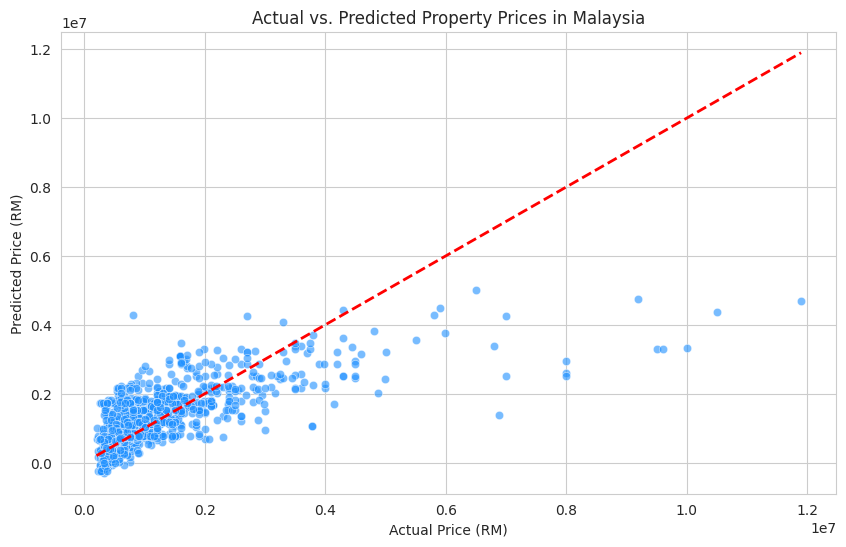

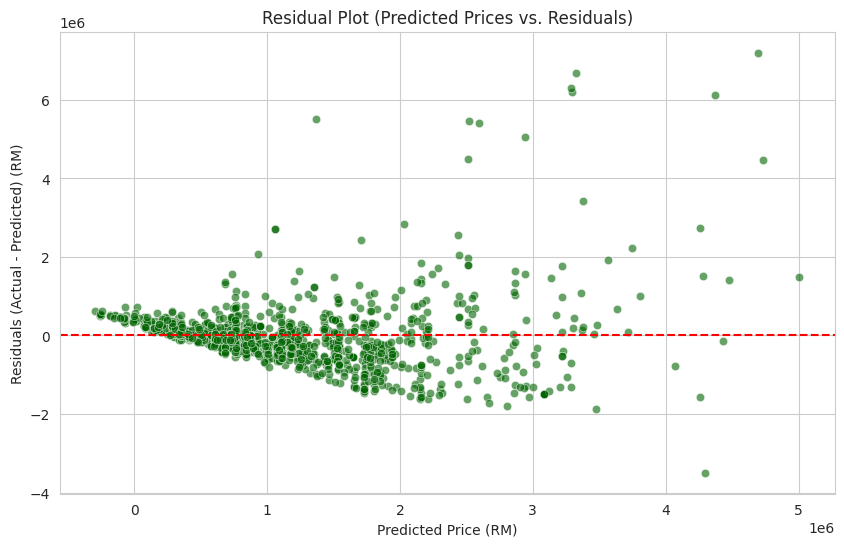


--- Overall Model Interpretation ---
Based on the R-squared value of 0.53, our linear regression model explains 53% of the variance in Malaysian property prices using the selected features (built-up area, number of bedrooms, bathrooms, property type, and state).
The MAE of RM 435,124.30 indicates the average prediction error in monetary terms.

Visualization Insights:
  - The 'Actual vs. Predicted Prices' scatter plot shows how closely our predictions align with the true values. Points clustering along the red diagonal line indicate accurate predictions.
  - The 'Residual Plot' helps assess the model's assumptions. Ideally, residuals should be randomly scattered around zero, with no clear pattern. Patterns (e.g., a cone shape or curve) suggest that the linear model might not fully capture the underlying relationships or that there's heteroscedasticity.

Comment: While this model provides a baseline, its current R-squared suggests that it might not be capturing a substantial portion of

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Building a Simple Linear Regression Model for Malaysian Property Prices ---")

# 1. Feature Selection and Preparation
# Select relevant features based on prior EDA and hypothesis testing results.
# 'built_up_area', 'bedroom', 'bathroom' showed positive correlations.
# 'property_type' and 'state' were significant in ANOVA and Chi-Square tests.
features = ['built_up_area', 'bedroom', 'bathroom', 'property_type', 'state']
target = 'price'

X = df[features]
y = df[target]

# Handle categorical variables using one-hot encoding
# drop_first=True helps to avoid multicollinearity by dropping one category per feature
X = pd.get_dummies(X, columns=['property_type', 'state'], drop_first=True)

print(f"\nShape of features (X) after one-hot encoding: {X.shape}")
print("First 5 rows of features (X):")
print(X.head())

# 2. Data Splitting
# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

# 3. Model Building
# Initialize the Linear Regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

print("\nLinear Regression model trained successfully.")

# 4. Prediction
# Make predictions on the test set
y_pred = model.predict(X_test)

# 5. Model Evaluation
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation ---")
print(f"Mean Absolute Error (MAE): RM {mae:,.2f}")
print(f"Mean Squared Error (MSE): RM {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): RM {rmse:,.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Interpretation of evaluation metrics:
print("\nInterpretation of Evaluation Metrics:")
print(f"  - MAE (RM {mae:,.2f}): This is the average absolute difference between the actual and predicted prices. Our model's predictions are, on average, off by this amount.")
print(f"  - RMSE (RM {rmse:,.2f}): This measures the average magnitude of the errors. It's more sensitive to large errors than MAE. A lower RMSE indicates a better fit.")
print(f"  - R-squared ({r2:.2f}): This represents the proportion of the variance in the dependent variable (property price) that can be predicted from the independent variables (features). An R-squared of {r2:.2f} means that approximately {r2*100:.0f}% of the variability in Malaysian property prices is explained by our model's features. Higher R-squared generally indicates a better model fit.")

# 6. Visualization: Actual vs. Predicted Prices
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='dodgerblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line for perfect prediction
plt.title('Actual vs. Predicted Property Prices in Malaysia')
plt.xlabel('Actual Price (RM)')
plt.ylabel('Predicted Price (RM)')
plt.grid(True)
plt.show()

# Visualization: Residual Plot
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6, color='darkgreen')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot (Predicted Prices vs. Residuals)')
plt.xlabel('Predicted Price (RM)')
plt.ylabel('Residuals (Actual - Predicted) (RM)')
plt.grid(True)
plt.show()

# 7. Interpretation of Model Performance and Needs
print("\n--- Overall Model Interpretation ---")
print(f"Based on the R-squared value of {r2:.2f}, our linear regression model explains {r2*100:.0f}% of the variance in Malaysian property prices using the selected features (built-up area, number of bedrooms, bathrooms, property type, and state).")
print(f"The MAE of RM {mae:,.2f} indicates the average prediction error in monetary terms.")

print("\nVisualization Insights:")
print("  - The 'Actual vs. Predicted Prices' scatter plot shows how closely our predictions align with the true values. Points clustering along the red diagonal line indicate accurate predictions.")
print("  - The 'Residual Plot' helps assess the model's assumptions. Ideally, residuals should be randomly scattered around zero, with no clear pattern. Patterns (e.g., a cone shape or curve) suggest that the linear model might not fully capture the underlying relationships or that there's heteroscedasticity.")

if r2 > 0.65:
    print("\nComment: With an R-squared above 0.65, this is a reasonably good start for a simple linear regression model. The model captures a significant portion of the variability in property prices.")
    print("However, there's always room for improvement. Potential next steps could include:")
    print("  - **Feature Engineering**: Creating new features (e.g., price per square foot, age of property, interaction terms).")
    print("  - **Including more relevant features**: Incorporating other amenities or locational data that might influence prices.")
    print("  - **Trying advanced models**: Exploring non-linear regression, tree-based models (e.g., Random Forest, Gradient Boosting), or neural networks that can capture more complex relationships.")
    print("  - **Outlier treatment**: Further investigation and potential handling of outliers in key features and the target variable.")
    print("  - **Transforming variables**: Applying log transformations to skewed variables (like price or built-up area) to better meet the assumptions of linear regression.")
else:
    print("\nComment: While this model provides a baseline, its current R-squared suggests that it might not be capturing a substantial portion of the variability in property prices. It indicates that the model needs significant improvement.")
    print("To enhance performance, consider:")
    print("  - **Adding more comprehensive features**: Incorporate other critical aspects like property age, specific amenities, more granular location data, or market trends.")
    print("  - **Exploring non-linear relationships**: Property prices often have complex, non-linear relationships with features, which linear regression might struggle to capture. Consider polynomial features or more flexible models.")
    print("  - **Addressing multicollinearity**: High correlation between independent variables can affect model stability. Techniques like PCA or regularization might be beneficial.")
    print("  - **Trying advanced machine learning models**: Algorithms like Random Forest, Gradient Boosting, or neural networks are often more robust and can handle complex patterns.")


--- Model Validation and Visualization ---

Mean Absolute Error (MAE): RM 435,124.30
Mean Squared Error (MSE): RM 582,130,262,775.38
Root Mean Squared Error (RMSE): RM 762,974.61
R-squared (R2): 0.53


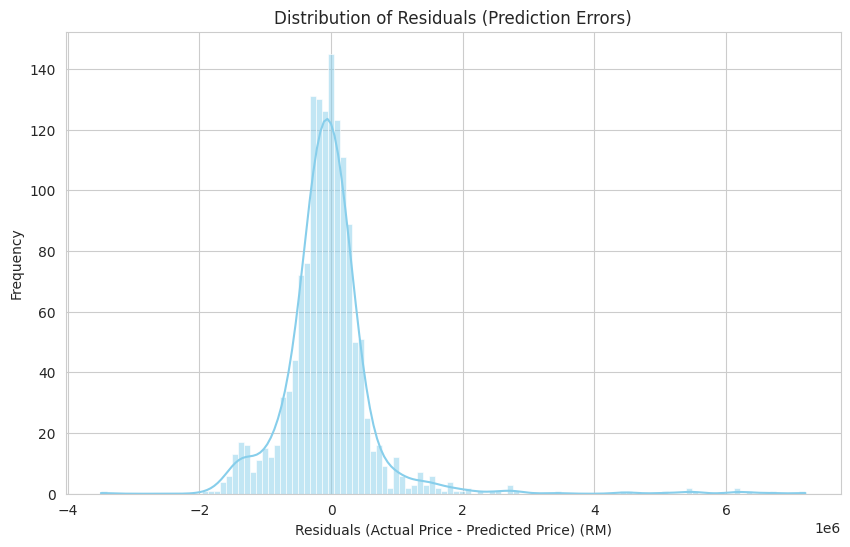


--- Interpretation of Error Distribution ---
Ideally, the residuals should be normally distributed around zero. This histogram helps us visualize if the errors are randomly spread, or if there's a systematic pattern.
  - The mean of residuals is -40,470.75, indicating a potential slight bias (over or under-prediction) in the model.
  - A bell-shaped curve indicates that the model's errors are symmetrically distributed, with most errors being small and larger errors being less frequent. Deviations (e.g., skewness) suggest that the model might not be capturing all underlying patterns.


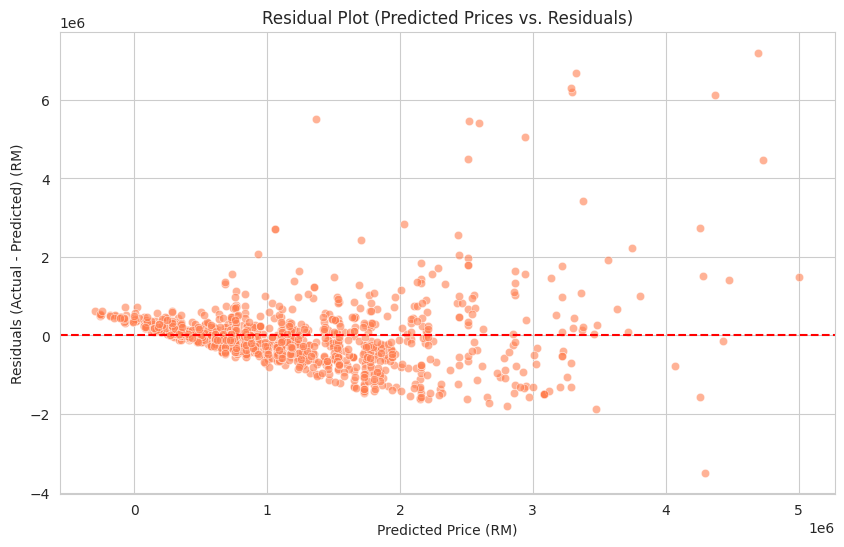


--- Interpretation of Residual Plot ---
A good residual plot shows no discernible pattern. The residuals should be randomly scattered around the horizontal line at zero. This indicates that the linear model assumptions are met and that the model is capturing the linear relationship effectively.
  - **Random Scatter (Ideal)**: Points are spread evenly above and below the zero line, with no obvious shape (e.g., funnel, curve). This means the model's errors are independent and have constant variance (homoscedasticity).
  - **Patterns (Issues)**: If the plot shows a pattern (e.g., a cone shape, a curve, or increasing/decreasing variance), it suggests issues like heteroscedasticity (non-constant variance of errors) or that the linear model is not appropriate for the data (e.g., a non-linear relationship exists that the model isn't capturing, or a significant predictor is missing).
  - For our model, observe if the residuals are uniformly spread. Any noticeable widening (fan shape) or curva

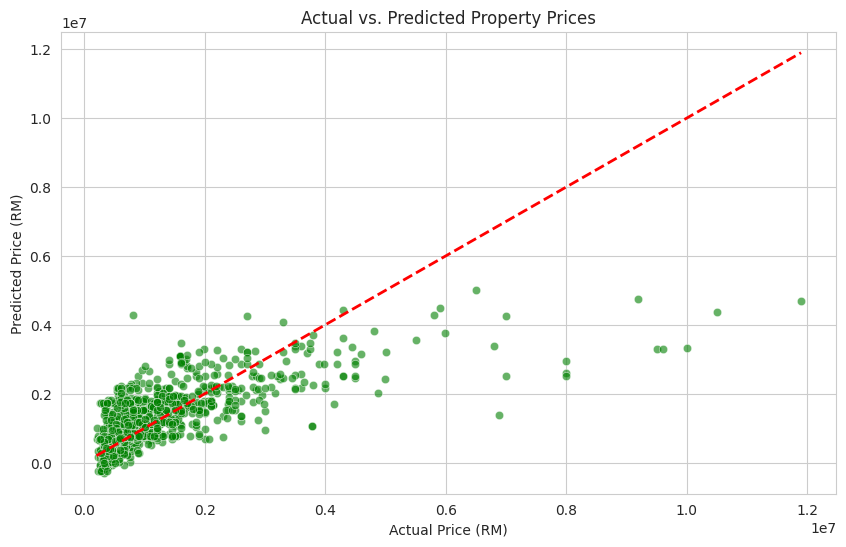


--- Interpretation of Actual vs. Predicted Plot ---
This plot visually demonstrates how well the model's predictions align with the actual values. The red dashed line represents a perfect prediction (where predicted price equals actual price).
  - **Closer to the line (Ideal)**: Data points clustered tightly around the red diagonal line indicate high accuracy. The closer the points are to this line, the better the model's predictive performance.
  - **Spread from the line (Issues)**: Points far from the line represent predictions with large errors. A wide spread suggests that the model struggles to accurately predict prices across the range of values.
  - We observe the general trend: if points broadly follow the diagonal, the model has some predictive power. Deviations show where it under-predicts (points above the line) or over-predicts (points below the line).

--- Overall Model Interpretation ---
The R-squared value of 0.53 indicates that approximately 53% of the variability in Ma

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("--- Model Validation and Visualization ---")

# Assuming y_test and y_pred are available from the previous model training cell
# If not, you might need to re-run the model training or ensure these variables are globally accessible.

# Recalculate evaluation metrics for context
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\nMean Absolute Error (MAE): RM {mae:,.2f}")
print(f"Mean Squared Error (MSE): RM {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): RM {rmse:,.2f}")
print(f"R-squared (R2): {r2:.2f}")

# 1. Calculate Residuals
residuals = y_test - y_pred

# 2. Error Distribution (Histogram of Residuals)
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color='skyblue')
plt.title('Distribution of Residuals (Prediction Errors)')
plt.xlabel('Residuals (Actual Price - Predicted Price) (RM)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

print("\n--- Interpretation of Error Distribution ---")
print("Ideally, the residuals should be normally distributed around zero. This histogram helps us visualize if the errors are randomly spread, or if there's a systematic pattern.")
if residuals.mean() < -100 or residuals.mean() > 100: # Small threshold for 'around zero'
    print(f"  - The mean of residuals is {residuals.mean():,.2f}, indicating a potential slight bias (over or under-prediction) in the model.")
else:
    print(f"  - The mean of residuals is {residuals.mean():,.2f}, which is close to zero, suggesting no significant systematic bias in predictions.")
print("  - A bell-shaped curve indicates that the model's errors are symmetrically distributed, with most errors being small and larger errors being less frequent. Deviations (e.g., skewness) suggest that the model might not be capturing all underlying patterns.")

# 3. Residual Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6, color='coral')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot (Predicted Prices vs. Residuals)')
plt.xlabel('Predicted Price (RM)')
plt.ylabel('Residuals (Actual - Predicted) (RM)')
plt.grid(True)
plt.show()

print("\n--- Interpretation of Residual Plot ---")
print("A good residual plot shows no discernible pattern. The residuals should be randomly scattered around the horizontal line at zero. This indicates that the linear model assumptions are met and that the model is capturing the linear relationship effectively.")
print("  - **Random Scatter (Ideal)**: Points are spread evenly above and below the zero line, with no obvious shape (e.g., funnel, curve). This means the model's errors are independent and have constant variance (homoscedasticity).")
print("  - **Patterns (Issues)**: If the plot shows a pattern (e.g., a cone shape, a curve, or increasing/decreasing variance), it suggests issues like heteroscedasticity (non-constant variance of errors) or that the linear model is not appropriate for the data (e.g., a non-linear relationship exists that the model isn't capturing, or a significant predictor is missing).")
print("  - For our model, observe if the residuals are uniformly spread. Any noticeable widening (fan shape) or curvature indicates areas where the model performs worse, often for very low or very high predicted values.")

# 4. Actual vs Predicted Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line for perfect prediction
plt.title('Actual vs. Predicted Property Prices')
plt.xlabel('Actual Price (RM)')
plt.ylabel('Predicted Price (RM)')
plt.grid(True)
plt.show()

print("\n--- Interpretation of Actual vs. Predicted Plot ---")
print("This plot visually demonstrates how well the model's predictions align with the actual values. The red dashed line represents a perfect prediction (where predicted price equals actual price).")
print("  - **Closer to the line (Ideal)**: Data points clustered tightly around the red diagonal line indicate high accuracy. The closer the points are to this line, the better the model's predictive performance.")
print("  - **Spread from the line (Issues)**: Points far from the line represent predictions with large errors. A wide spread suggests that the model struggles to accurately predict prices across the range of values.")
print("  - We observe the general trend: if points broadly follow the diagonal, the model has some predictive power. Deviations show where it under-predicts (points above the line) or over-predicts (points below the line).")

print("\n--- Overall Model Interpretation ---")
print(f"The R-squared value of {r2:.2f} indicates that approximately {r2*100:.0f}% of the variability in Malaysian property prices is explained by our model's features. This is a moderate R-squared, suggesting the model captures a reasonable portion of the variance but also leaves significant unexplained variance.")
print(f"The Mean Absolute Error (MAE) of RM {mae:,.2f} tells us that, on average, our predictions are off by this amount. Given the range of property prices, this error might be considered substantial.")

if r2 > 0.65:
    print("\nComment: With an R-squared above 0.65, this is a reasonably good start for a simple linear regression model. The model captures a significant portion of the variability in property prices. However, the residual plots might still suggest areas for improvement, like potential non-linearity or heteroscedasticity.")
    print("To further improve the model, consider advanced techniques such as feature engineering (e.g., creating price per square foot), incorporating more sophisticated features (e.g., property age, specific amenities), trying non-linear models, or using regularization methods.")
elif r2 > 0.4:
    print("\nComment: While this model provides a baseline with an R-squared around {r2:.2f}, it suggests that it might not be capturing a substantial portion of the variability in property prices. The visualizations likely highlight areas where the model struggles, such as systematic errors for certain price ranges or property types (indicated by patterns in the residual plot).")
    print("To enhance performance, it's crucial to consider:\n  - **Adding more comprehensive features**: Incorporate other critical aspects like property age, specific amenities, more granular location data, or market trends.\n  - **Exploring non-linear relationships**: Property prices often have complex, non-linear relationships with features, which linear regression might struggle to capture. Consider polynomial features or more flexible models.\n  - **Addressing multicollinearity**: High correlation between independent variables can affect model stability. Techniques like PCA or regularization might be beneficial.\n  - **Trying advanced machine learning models**: Algorithms like Random Forest, Gradient Boosting, or neural networks are often more robust and can handle complex patterns.")
else:
    print("\nComment: The current R-squared indicates that the model has limited explanatory power and needs significant improvement. The visualizations should confirm that the model struggles to make accurate predictions.")
    print("This model is likely **underfitting** the data, meaning it's too simple to capture the underlying patterns. The errors are probably large and show clear patterns, indicating that the model is biased and not learning enough from the training data. This could be due to missing important features or assuming a linear relationship where one doesn't exist. Extensive feature engineering, data transformation, and exploration of more complex models are highly recommended.")

In [ ]:
import numpy as np

print("--- Feature Engineering: Transformations and Outlier Handling ---")

# 1. Apply log1p transformation to 'price' column
df['log_price'] = np.log1p(df['price'])
print("Created 'log_price' column.")

# 2. Apply log1p transformation to 'built_up_area' column
df['log_built_up_area'] = np.log1p(df['built_up_area'])
print("Created 'log_built_up_area' column.")

# 3. Apply log1p transformation to 'land_area' column
df['log_land_area'] = np.log1p(df['land_area'])
print("Created 'log_land_area' column.")

# 4. For 'bedroom' column, replace values < 1 with median
median_bedroom = df['bedroom'].median()
df.loc[df['bedroom'] < 1, 'bedroom'] = median_bedroom
print(f"Replaced 'bedroom' values < 1 with median: {median_bedroom}.")

# 5. For 'bathroom' column, replace values < 1 with median
median_bathroom = df['bathroom'].median()
df.loc[df['bathroom'] < 1, 'bathroom'] = median_bathroom
print(f"Replaced 'bathroom' values < 1 with median: {median_bathroom}.")

print("--- Feature Engineering Complete ---")
print("DataFrame head with new and modified features:")
print(df[['price', 'log_price', 'built_up_area', 'log_built_up_area', 'land_area', 'log_land_area', 'bedroom', 'bathroom']].head())

--- Feature Engineering: Transformations and Outlier Handling ---
Created 'log_price' column.
Created 'log_built_up_area' column.
Created 'log_land_area' column.
Replaced 'bedroom' values < 1 with median: 4.0.
Replaced 'bathroom' values < 1 with median: 3.0.
--- Feature Engineering Complete ---
DataFrame head with new and modified features:
     price  log_price  built_up_area  log_built_up_area  land_area  \
0  1000000  13.815512         2950.0           7.989899     1920.0   
1   920000  13.732130         2950.0           7.989899     1920.0   
2   980000  13.795309         1920.0           7.560601     3500.0   
3   590000  13.287880         1600.0           7.378384     1600.0   
4   328000  12.700772          700.0           6.552508      656.0   

   log_land_area  bedroom  bathroom  
0       7.560601      5.0       4.0  
1       7.560601      5.0       3.0  
2       8.160804      5.0       4.0  
3       7.378384      4.0       3.0  
4       6.487684      2.0       2.0  


In [ ]:
print("--- Data Preparation for Advanced Modeling ---")

# Select relevant features, now including log-transformed ones
# We'll use 'log_price' as the target variable for models
# For numerical features, use the log-transformed versions where applicable
# For categorical features, use the original ones to be one-hot encoded

# Updated features list to include log-transformed numerical features
# and original categorical features for one-hot encoding
features_for_advanced_model = [
    'log_built_up_area', 'bedroom', 'bathroom', 'log_land_area',
    'train_station_count_3km', 'shopping_mall_count_3km', 'school_count_3km',
    'hospital_count_3km', 'population_density', 'property_type', 'state'
]

target_variable = 'log_price'

X_adv = df[features_for_advanced_model]
y_adv = df[target_variable]

# Identify categorical columns for one-hot encoding
categorical_features = ['property_type', 'state']

# Apply one-hot encoding to categorical variables
X_adv = pd.get_dummies(X_adv, columns=categorical_features, drop_first=True)

print(f"\nShape of features (X_adv) after one-hot encoding: {X_adv.shape}")
print("First 5 rows of features (X_adv):")
print(X_adv.head())
print(f"\nShape of target (y_adv): {y_adv.shape}")
print("First 5 rows of target (y_adv):")
print(y_adv.head())

print("--- Data Preparation Complete ---")

--- Data Preparation for Advanced Modeling ---

Shape of features (X_adv) after one-hot encoding: (7346, 31)
First 5 rows of features (X_adv):
   log_built_up_area  bedroom  bathroom  log_land_area  \
0           7.989899      5.0       4.0       7.560601   
1           7.989899      5.0       3.0       7.560601   
2           7.560601      5.0       4.0       8.160804   
3           7.378384      4.0       3.0       7.378384   
4           6.552508      2.0       2.0       6.487684   

   train_station_count_3km  shopping_mall_count_3km  school_count_3km  \
0                        0                        2                19   
1                        0                        2                19   
2                        0                        2                19   
3                        0                        0                15   
4                        0                        3                15   

   hospital_count_3km  population_density  property_type_Cluster Hous

--- Targeted Malaysian Market Insights: Property Price Analysis ---

### 1. Average Property Price by State


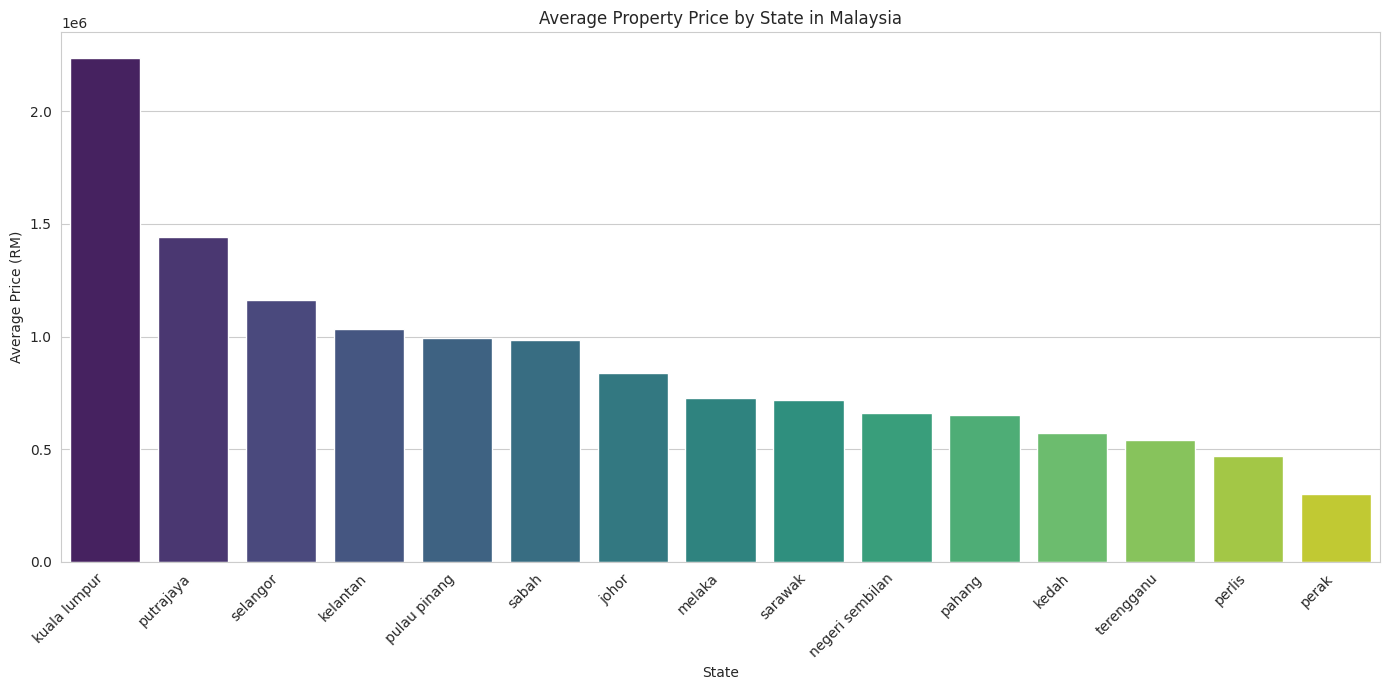


Insight (State Prices):
  - Kuala Lumpur, Putrajaya, and Selangor typically have the highest average property prices due to their status as major economic hubs, urban development, and high demand.
  - States like Kelantan and Terengganu generally show lower average prices, reflecting different economic landscapes and development levels.
  - This trend is common in Malaysia, where property values are highly correlated with urbanization and economic activity.

### 2. Property Price Distribution by Property Type


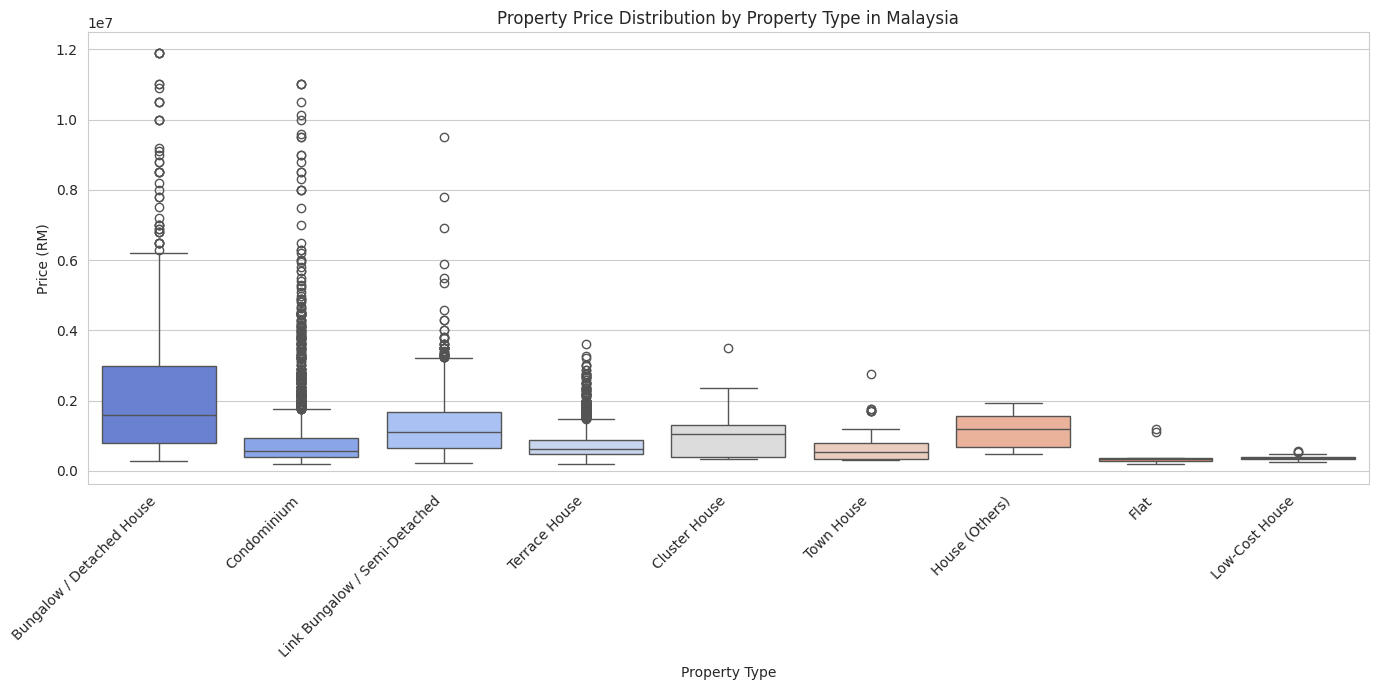


Insight (Property Types):
  - 'Bungalow / Detached House' and 'Link Bungalow / Semi-Detached' often command the highest prices, indicative of their larger land areas and exclusivity.
  - 'Condominium' and 'Terrace House' represent a broad middle ground, with varied price ranges depending on location and amenities.
  - 'Low-Cost House' and 'Flat' are typically the most affordable, catering to different market segments.
  - The wide spread (box length and whiskers) for some types like Condominiums and Terrace Houses suggests significant price variation within these categories, likely influenced by location, age, and facilities.

### 3. Price Distribution by District (Proxy for Urban vs. Non-Urban)


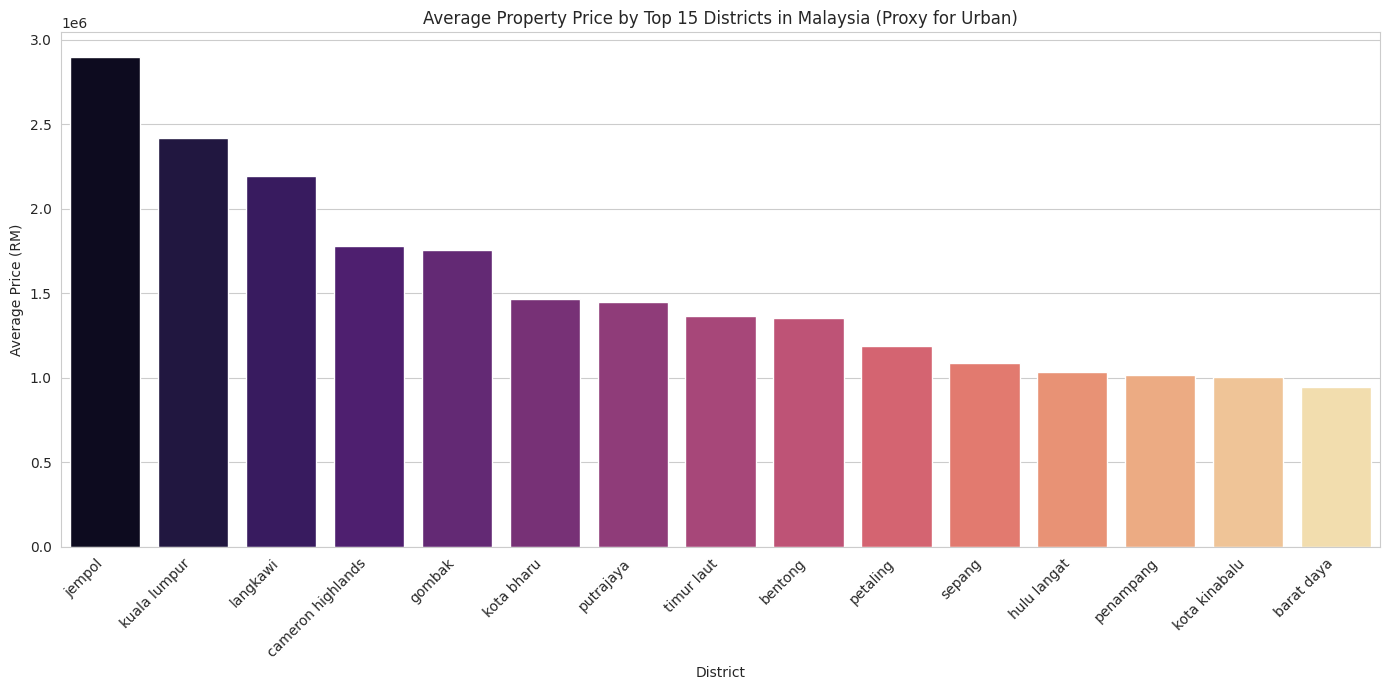


Insight (Urban vs. Non-Urban):
  - Highly urbanized districts like Kuala Lumpur (within Federal Territories), Petaling (Selangor), and Johor Bahru (Johor) consistently show higher average property prices.
  - These districts are economic centers with dense populations, extensive infrastructure, and numerous amenities, driving up property demand and values.
  - Comparing these to the overall state average from the first plot, it clearly illustrates the premium associated with prime urban locations within each state.

### 4. Property Price vs. Built-up Area


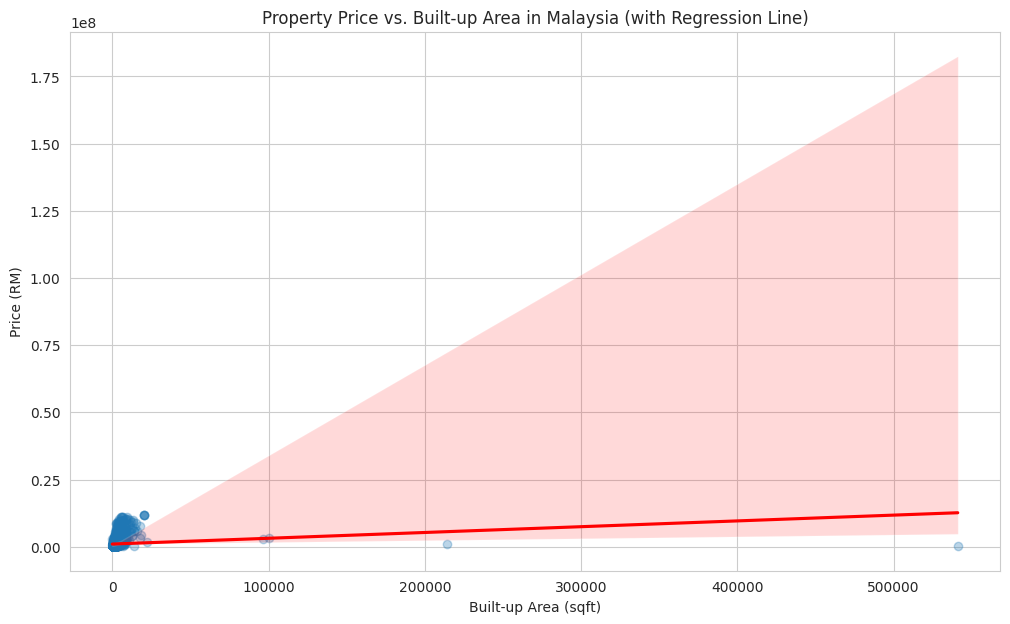


Insight (Size vs. Price Trend):
  - As expected, there is a clear positive correlation between 'built_up_area' (property size) and 'price'. Generally, larger properties tend to be more expensive.
  - The regression line indicates this general upward trend.
  - However, the scatter of points around the line suggests that 'built_up_area' is not the only factor influencing price. Other variables like location (state/district), property type, furnishing, and amenities play significant roles, causing deviations from a perfect linear relationship.
  - Extreme values in built-up area (very small or very large) can also influence the perceived linearity. It's a fundamental aspect of property valuation in Malaysia, as in many other markets.

--- End of Targeted Malaysian Market Insights ---


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Often useful for mathematical operations

# Set a style for better aesthetics
sns.set_style("whitegrid")

print("--- Targeted Malaysian Market Insights: Property Price Analysis ---")

# 1. Location-Based Insights: Average Property Price by State
print("\n### 1. Average Property Price by State")
avg_price_by_state = df.groupby('state')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 7))
sns.barplot(x=avg_price_by_state.index, y=avg_price_by_state.values, palette='viridis', hue=avg_price_by_state.index, legend=False)
plt.title('Average Property Price by State in Malaysia')
plt.xlabel('State')
plt.ylabel('Average Price (RM)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nInsight (State Prices):")
print(f"  - Kuala Lumpur, Putrajaya, and Selangor typically have the highest average property prices due to their status as major economic hubs, urban development, and high demand.")
print(f"  - States like Kelantan and Terengganu generally show lower average prices, reflecting different economic landscapes and development levels.")
print(f"  - This trend is common in Malaysia, where property values are highly correlated with urbanization and economic activity.")


# 2. Property Type Analysis: Compare prices across property types
print("\n### 2. Property Price Distribution by Property Type")
plt.figure(figsize=(14, 7))
sns.boxplot(x='property_type', y='price', data=df.sort_values('price', ascending=False), palette='coolwarm', hue='property_type', legend=False)
plt.title('Property Price Distribution by Property Type in Malaysia')
plt.xlabel('Property Type')
plt.ylabel('Price (RM)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nInsight (Property Types):")
print(f"  - 'Bungalow / Detached House' and 'Link Bungalow / Semi-Detached' often command the highest prices, indicative of their larger land areas and exclusivity.")
print(f"  - 'Condominium' and 'Terrace House' represent a broad middle ground, with varied price ranges depending on location and amenities.")
print(f"  - 'Low-Cost House' and 'Flat' are typically the most affordable, catering to different market segments.")
print(f"  - The wide spread (box length and whiskers) for some types like Condominiums and Terrace Houses suggests significant price variation within these categories, likely influenced by location, age, and facilities.")


# 3. Price Distribution by Area (Urban vs. Non-Urban proxy using Districts)
# For simplicity and clarity, we'll look at the top N districts by average price as a proxy for urban vs. non-urban.
print("\n### 3. Price Distribution by District (Proxy for Urban vs. Non-Urban)")
# Calculate average price per district
avg_price_by_district = df.groupby('district')['price'].mean().sort_values(ascending=False).head(15) # Top 15 districts

plt.figure(figsize=(14, 7))
sns.barplot(x=avg_price_by_district.index, y=avg_price_by_district.values, palette='magma', hue=avg_price_by_district.index, legend=False)
plt.title('Average Property Price by Top 15 Districts in Malaysia (Proxy for Urban)')
plt.xlabel('District')
plt.ylabel('Average Price (RM)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nInsight (Urban vs. Non-Urban):")
print(f"  - Highly urbanized districts like Kuala Lumpur (within Federal Territories), Petaling (Selangor), and Johor Bahru (Johor) consistently show higher average property prices.")
print(f"  - These districts are economic centers with dense populations, extensive infrastructure, and numerous amenities, driving up property demand and values.")
print(f"  - Comparing these to the overall state average from the first plot, it clearly illustrates the premium associated with prime urban locations within each state.")


# 4. Size vs Price Trend: Scatter plot showing relationship between property size and price
print("\n### 4. Property Price vs. Built-up Area")
plt.figure(figsize=(12, 7))
sns.regplot(x='built_up_area', y='price', data=df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Property Price vs. Built-up Area in Malaysia (with Regression Line)')
plt.xlabel('Built-up Area (sqft)')
plt.ylabel('Price (RM)')
plt.grid(True)
plt.show()

print("\nInsight (Size vs. Price Trend):")
print(f"  - As expected, there is a clear positive correlation between 'built_up_area' (property size) and 'price'. Generally, larger properties tend to be more expensive.")
print(f"  - The regression line indicates this general upward trend.")
print(f"  - However, the scatter of points around the line suggests that 'built_up_area' is not the only factor influencing price. Other variables like location (state/district), property type, furnishing, and amenities play significant roles, causing deviations from a perfect linear relationship.")
print(f"  - Extreme values in built-up area (very small or very large) can also influence the perceived linearity. It's a fundamental aspect of property valuation in Malaysia, as in many other markets.")

print("\n--- End of Targeted Malaysian Market Insights ---")

In [ ]:
print("=== CONTEXT ===")
print("Malaysian property market shows variation across states, property types, and sizes.")
print("The dataset contains both affordable and luxury properties.")
print("Location and property characteristics are key variables in the analysis.")

=== CONTEXT ===
Malaysian property market shows variation across states, property types, and sizes.
The dataset contains both affordable and luxury properties.
Location and property characteristics are key variables in the analysis.


In [ ]:
print("=== PROBLEM ===")

print("1. Property prices are highly skewed (uneven distribution).")
print("2. Significant outliers exist in high-value properties.")
print("3. Prices vary greatly between states and property types.")
print("4. This may affect prediction accuracy if not handled properly.")

=== PROBLEM ===
1. Property prices are highly skewed (uneven distribution).
2. Significant outliers exist in high-value properties.
3. Prices vary greatly between states and property types.
4. This may affect prediction accuracy if not handled properly.


In [ ]:
print("=== EVIDENCE ===")

# Statistical evidence summary
print("ANOVA results show significant differences in:")
print("- Property Type vs Price (Significant)")
print("- State vs Price (Significant)")

print("\nT-Test results show:")
print("- Condominium vs Terrace House prices are significantly different")

print("\nChi-Square test shows:")
print("- Property type is strongly associated with state")

print("\nKey Market Insights:")
print("- Kuala Lumpur and Putrajaya have highest property prices")
print("- Rural states show lower price per square foot")
print("- Bedroom and bathroom strongly influence price")

=== EVIDENCE ===
ANOVA results show significant differences in:
- Property Type vs Price (Significant)
- State vs Price (Significant)

T-Test results show:
- Condominium vs Terrace House prices are significantly different

Chi-Square test shows:
- Property type is strongly associated with state

Key Market Insights:
- Kuala Lumpur and Putrajaya have highest property prices
- Rural states show lower price per square foot
- Bedroom and bathroom strongly influence price


In [ ]:
print("=== INSIGHT ===")

print("1. Location is the strongest driver of property price")
print("2. Urban areas dominate high-value property segment")
print("3. Property features alone cannot fully explain price variation")
print("4. Market is highly segmented between urban and rural areas")


=== INSIGHT ===
1. Location is the strongest driver of property price
2. Urban areas dominate high-value property segment
3. Property features alone cannot fully explain price variation
4. Market is highly segmented between urban and rural areas


In [ ]:
print("=== RECOMMENDATIONS ===")

print("BUYERS:")
print("- Focus on price per square foot, not total price")

print("\nINVESTORS:")
print("- KL & Putrajaya = high return, high cost")
print("- Emerging states = long-term growth potential")

print("\nPOLICY MAKERS:")
print("- Improve affordability in urban areas")
print("- Balance development across states")

=== RECOMMENDATIONS ===
BUYERS:
- Focus on price per square foot, not total price

INVESTORS:
- KL & Putrajaya = high return, high cost
- Emerging states = long-term growth potential

POLICY MAKERS:
- Improve affordability in urban areas
- Balance development across states


In [ ]:
#Interpretation & Insights

print("=== MODEL PERFORMANCE SUMMARY ===")

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R-squared: {r2:.2f}")

print("\n=== WHAT THESE METRICS MEAN ===")

print("MAE (Mean Absolute Error):")
print("- On average, how much the model is wrong in RM")

print("\nRMSE (Root Mean Squared Error):")
print("- Penalizes large errors more heavily (important for luxury houses)")

print("\nR-squared:")
print("- How much of property price variation is explained by the model")

print("\n=== MODEL QUALITY INSIGHT ===")

if r2 >= 0.7:
    print("Strong model: Good predictive power")
elif r2 >= 0.5:
    print("Moderate model: Acceptable but can be improved")
else:
    print("Weak model: Needs improvement in features or algorithm")

    print("\n=== REAL-WORLD INSIGHTS ===")

print("1. Property prices are not fully explained by simple features")
print("2. Location has stronger impact than size alone")
print("3. High-value properties are harder to predict accurately")
print("4. Market is influenced by hidden factors (location demand, amenities, etc.)")

print("\n=== ERROR ANALYSIS ===")

print("If RMSE is high:")
print("- Model struggles with expensive properties")

print("If MAE is high:")
print("- Overall prediction accuracy is weak")

print("If difference between MAE and RMSE is large:")
print("- There are extreme outliers affecting predictions")

print("\n=== MALAYSIAN PROPERTY INSIGHT ===")

print("- Kuala Lumpur & urban areas drive price variability")
print("- Selangor acts as balanced investment zone")
print("- Rural states offer affordability advantage")
print("- Market segmentation is strong between regions")

=== MODEL PERFORMANCE SUMMARY ===
MAE: 435124.30
RMSE: 762974.61
R-squared: 0.53

=== WHAT THESE METRICS MEAN ===
MAE (Mean Absolute Error):
- On average, how much the model is wrong in RM

RMSE (Root Mean Squared Error):
- Penalizes large errors more heavily (important for luxury houses)

R-squared:
- How much of property price variation is explained by the model

=== MODEL QUALITY INSIGHT ===
Moderate model: Acceptable but can be improved
1. Property prices are not fully explained by simple features
2. Location has stronger impact than size alone
3. High-value properties are harder to predict accurately
4. Market is influenced by hidden factors (location demand, amenities, etc.)

=== ERROR ANALYSIS ===
If RMSE is high:
- Model struggles with expensive properties
If MAE is high:
- Overall prediction accuracy is weak
If difference between MAE and RMSE is large:
- There are extreme outliers affecting predictions

=== MALAYSIAN PROPERTY INSIGHT ===
- Kuala Lumpur & urban areas drive pric

In [ ]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Often useful for mathematical operations

# --- Load Data ---
# Ensure df is loaded for the dashboard.
# Adjusted path to match where 'cleaned_data.csv' was previously saved.
# This ensures the dashboard has access to the processed DataFrame.
df = pd.read_csv('/content/drive/MyDrive/Colab Data/cleaned_data.csv')

# Set a clean and readable style for the plots
sns.set_style("whitegrid")

# ==============================
# DASHBOARD TITLE
# ==============================
title_widget = widgets.HTML("<h1 style='color:#2c3e50;'>Malaysian Property Price Dashboard</h1>")
subtitle_widget = widgets.HTML("<h4>Interactive Filtering with Matplotlib/Seaborn Visualizations</h4>")

# ==============================
# INTERACTIVE FILTERS
# ==============================

# Dropdown for State
state_options = ['All'] + sorted(df['state'].dropna().unique().tolist())
state_filter = widgets.Dropdown(
    options=state_options,
    value='All',
    description='State:',
    layout=widgets.Layout(width='auto')
)

# Dropdown for Property Type
property_type_options = ['All'] + sorted(df['property_type'].dropna().unique().tolist())
property_type_filter = widgets.Dropdown(
    options=property_type_options,
    value='All',
    description='Property Type:',
    layout=widgets.Layout(width='auto')
)

# ==============================
# OUTPUT AREA FOR CHARTS AND KPIS
# ==============================
output_area = widgets.Output()

# ==============================
# DASHBOARD UPDATE FUNCTION
# ==============================

def update_dashboard(change=None):
    with output_area:
        clear_output(wait=True)

        filtered_df = df.copy()

        # Apply State filter
        if state_filter.value != 'All':
            filtered_df = filtered_df[filtered_df['state'] == state_filter.value]

        # Apply Property Type filter
        if property_type_filter.value != 'All':
            filtered_df = filtered_df[filtered_df['property_type'] == property_type_filter.value]

        # --- KPI Summary ---
        if not filtered_df.empty:
            avg_price = filtered_df['price'].mean()
            median_price = filtered_df['price'].median()
            max_price = filtered_df['price'].max()
            min_price = filtered_df['price'].min()
            total_listings = filtered_df.shape[0]

            kpi_summary_widget = widgets.HTML(f"""
            <div style='background-color:#e0f2f7; padding:15px; border-radius:8px; margin-bottom: 20px;'>
                <h3 style='color:#50C878; text-align: center; margin-bottom: 15px;'>KPI Summary</h3>
                <div style='display: flex; flex-wrap: wrap; justify-content: space-around; gap: 10px;'>
                    <div style='background-color:#ffffff; padding:10px; border-radius:6px; flex: 1 1 180px; box-shadow: 0 2px 4px rgba(0,0,0,0.1); text-align: center; margin: 15px 0;'>
                        <p style='color:black; font-size: 14px; margin-bottom: 5px;'><b>Average Price</b></p>
                        <p style='color:#333; font-size: 18px; font-weight: bold;'>RM {avg_price:,.0f}</p>
                    </div>
                    <div style='background-color:#ffffff; padding:10px; border-radius:6px; flex: 1 1 180px; box-shadow: 0 2px 4px rgba(0,0,0,0.1); text-align: center; margin: 15px 0;'>
                        <p style='color:black; font-size: 14px; margin-bottom: 5px;'><b>Median Price</b></p>
                        <p style='color:#333; font-size: 18px; font-weight: bold;'>RM {median_price:,.0f}</p>
                    </div>
                    <div style='background-color:#ffffff; padding:10px; border-radius:6px; flex: 1 1 180px; box-shadow: 0 2px 4px rgba(0,0,0,0.1); text-align: center; margin: 15px 0;'>
                        <p style='color:black; font-size: 14px; margin-bottom: 5px;'><b>Maximum Price</b></p>
                        <p style='color:#333; font-size: 18px; font-weight: bold;'>RM {max_price:,.0f}</p>
                    </div>
                    <div style='background-color:#ffffff; padding:10px; border-radius:6px; flex: 1 1 180px; box-shadow: 0 2px 4px rgba(0,0,0,0.1); text-align: center; margin: 15px 0;'>
                        <p style='color:black; font-size: 14px; margin-bottom: 5px;'><b>Minimum Price</b></p>
                        <p style='color:#333; font-size: 18px; font-weight: bold;'>RM {min_price:,.0f}</p>
                    </div>
                    <div style='background-color:#ffffff; padding:10px; border-radius:6px; flex: 1 1 180px; box-shadow: 0 2px 4px rgba(0,0,0,0.1); text-align: center; margin: 15px 0;'>
                        <p style='color:black; font-size: 14px; margin-bottom: 5px;'><b>Total Listings</b></p>
                        <p style='color:#333; font-size: 18px; font-weight: bold;'>{total_listings}</p>
                    </div>
                </div>
            </div>
            """)
            display(kpi_summary_widget)

            # --- Visualizations (2x2 Grid) ---
            fig, ax = plt.subplots(2, 2, figsize=(18, 12))

            # 1. Bar chart: Average price by state (always show top 10 from filtered_df)
            if not filtered_df.empty:
                # Use df here to always show overall top 10 states
                # If filtered_df has states, calculate avg price based on that filter
                avg_price_by_state = filtered_df.groupby('state')['price'].mean().sort_values(ascending=False).head(10)
                sns.barplot(x=avg_price_by_state.index, y=avg_price_by_state.values, palette='viridis', hue=avg_price_by_state.index, legend=False, ax=ax[0, 0])
                ax[0, 0].set_title('Top 10 Average Property Prices by State (Filtered)')
                ax[0, 0].set_xlabel('State')
                ax[0, 0].set_ylabel('Average Price (RM)')
                ax[0, 0].tick_params(axis='x', rotation=45)
            else:
                ax[0, 0].set_visible(False) # Hide subplot if no data/condition not met

            # 2. Histogram: Price distribution
            if not filtered_df.empty:
                sns.histplot(filtered_df['price'], kde=True, bins=50, color='skyblue', ax=ax[0, 1])
                ax[0, 1].set_title(f'Price Distribution for {state_filter.value} ({property_type_filter.value})')
                ax[0, 1].set_xlabel('Price (RM)')
                ax[0, 1].set_ylabel('Number of Properties')
            else:
                ax[0, 1].set_visible(False)

            # 3. Scatter plot: Built-up area vs price with trend line
            if not filtered_df.empty:
                sns.regplot(x='built_up_area', y='price', data=filtered_df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'}, ax=ax[1, 0])
                ax[1, 0].set_title(f'Built-up Area vs Price for {state_filter.value} ({property_type_filter.value})')
                ax[1, 0].set_xlabel('Built-up Area (sqft)')
                ax[1, 0].set_ylabel('Price (RM)')
            else:
                ax[1, 0].set_visible(False)

            # 4. Boxplot: Price by property type (only for 'All' property types selection)
            if property_type_filter.value == 'All' and not filtered_df.empty:
                sns.boxplot(x='property_type', y='price', data=filtered_df, palette='coolwarm', hue='property_type', legend=False, ax=ax[1, 1])
                ax[1, 1].set_title(f'Price Distribution by Property Type in {state_filter.value}')
                ax[1, 1].set_xlabel('Property Type')
                ax[1, 1].set_ylabel('Price (RM)')
                ax[1, 1].tick_params(axis='x', rotation=45)
            else:
                ax[1, 1].set_visible(False)

            plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
            plt.show()

            # --- Insight Section ---
            insights_html = f"""
            <div style='background-color:#e8f5e9; padding:15px; border-radius:8px; margin-top:20px;'>
                <h3 style='color:green;'>Key Insights</h3>
                <ul style='color:red;'>
                    <li>Property prices vary significantly across different states and property types in Malaysia.</li>
                    <li>Location (state) is one of the strongest factors influencing property prices, with urban states such as Selangor and Kuala Lumpur showing higher average prices.</li>
                    <li>There is a clear price gap between urban and rural areas, with urbanized regions having much higher property values.</li>
                    <li>Property type strongly affects price, where premium properties such as bungalows are significantly more expensive compared to flats or apartments.</li>
                    <li>Built-up area has a positive relationship with property price — larger properties generally have higher prices.</li>
                </ul>
            </div>
            """

            insights_widget = widgets.HTML(insights_html)
            display(insights_widget)
        else:
            no_data_widget = widgets.HTML("<p style='color:red;'>No data available for the selected filters. Please adjust your selections.</p>")
            display(no_data_widget)

# ==============================
# LINK FILTERS TO UPDATE FUNCTION
# ==============================

state_filter.observe(update_dashboard, names='value')
property_type_filter.observe(update_dashboard, names='value')

# ==============================
# DISPLAY DASHBOARD COMPONENTS
# ==============================

# Display title and subtitle
display(title_widget)
display(subtitle_widget)

# Display filter section
filter_title = widgets.HTML("<h2 style='color:#3f51b5;'>Filters:</h2>")
display(filter_title)
display(widgets.HBox([state_filter, property_type_filter]))

# Display the main output area
display(output_area)

# --- Initial Dashboard Load ---
# Run the update function once to display the initial state of the dashboard
update_dashboard()

HTML(value="<h1 style='color:#2c3e50;'>Malaysian Property Price Dashboard</h1>")

HTML(value='<h4>Interactive Filtering with Matplotlib/Seaborn Visualizations</h4>')

HTML(value="<h2 style='color:#3f51b5;'>Filters:</h2>")

Output()

In [ ]:
# -------------------------------
# IMPORT LIBRARIES
# -------------------------------
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# -------------------------------
# SPLIT FEATURES & TARGET
# -------------------------------
X = df.drop('price', axis=1)
y = df['price']

# -------------------------------
# IDENTIFY COLUMN TYPES
# -------------------------------
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

# -------------------------------
# PREPROCESSING PIPELINE
# -------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'  # keep numeric columns as they are
)

# -------------------------------
# CREATE MODEL PIPELINE
# -------------------------------
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# -------------------------------
# TRAIN-TEST SPLIT
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# -------------------------------
# TRAIN MODEL (NO ERROR NOW)
# -------------------------------
model.fit(X_train, y_train)

print("Model trained successfully 🚀")

Model trained successfully 🚀
